# 3.3.2 通道改变与平衡集合

## 学习目标与先修知识

能比较双向、单向与完全断开的交换，说明平衡（equilibrium）集合与初始总量如何共同决定长期状态（state），辨认坐标尺度造成的视觉变化。

先修：封闭两室解析解（analytical solution）、平衡方程和相平面（phase plane）。 [复习上一节](01-向量场相轨迹与时间.ipynb)。

## 具体问题

把回流通道关闭后，物质会消失、均分，还是聚在某一室？如果两个通道都关闭，原来的平衡结论还适用吗？

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from systems_science import plot_style, show_table
plot_style()
BLUE, PINK = '#008bfb', '#ff0051'

## 初步实验

先计算一个具体情形，再解释这些数是怎样相互制约的。

In [2]:
for a,b in [(.2,.1),(.2,0),(0,.1),(0,0)]:
    print('a,b =',a,b,'；从 [6,0] 出发的变化率 =',[-6*a,6*a])

a,b = 0.2 0.1 ；从 [6,0] 出发的变化率 = [-1.2000000000000002, 1.2000000000000002]
a,b = 0.2 0 ；从 [6,0] 出发的变化率 = [-1.2000000000000002, 1.2000000000000002]
a,b = 0 0.1 ；从 [6,0] 出发的变化率 = [0, 0]
a,b = 0 0 ；从 [6,0] 出发的变化率 = [0, 0]


## 模型假设

封闭两室非负所追踪物质总量（tracked amount），u=c=0，初始总量固定为 6 U。a、b 均非负，关闭通道意味着系数取零；不额外增加清除。相图（phase portrait）两个坐标同单位，比较时使用相同范围与等比例轴。

## 数学解释与推导

封闭条件给 $S=A_1+A_2$ 不变。若 a+b>0，则
$$\dot A_1=bS-(a+b)A_1,\quad A_1(t)=A_1^*+(A_1(0)-A_1^*)e^{-(a+b)t},\quad A_1^*=\frac{bS}{a+b}.$$
每个初值（initial condition）沿自身的总量直线运动，不会穿越到别的总量直线。a,b>0 时平衡集合为 $aA_1=bA_2$。非负区域内是一条射线；固定 S 后选出一点，而不是整个系统只存在一个平衡。

若 a>0、b=0，$A_1=A_1(0)e^{-at}$，所有物质最终转到室 2；平衡集合为 A1=0。若 a=0、b>0，则最终转到室 1；平衡集合为 A2=0。若 a=b=0，$\dot x=0$，每一点都是平衡，原公式分母为零，应直接保持初值。

封闭模型（model）的零特征值（eigenvalue）使它不能把不同总量的任意邻近点都吸到同一个平衡。沿固定总量方向，分配偏差会衰减；沿改变总量的方向，终点会改变。这是“在守恒约束内靠近”和“全平面吸引到一点”的区别。

显示坐标的横向拉伸不改变上述方程、平衡或守恒。如果换变量 z=Hx（H 可逆），需要同步改成 $\dot z=HMH^{-1}z$，这才是数学上的坐标变换。改变图框比例只是显示选择，不能据此推断交换增强或速度增大。

实现把同一解析式写成初值与平衡分配的加权和：令 q=exp(−(a+b)t)，w=1−q，则 Ai(t)=q Ai(0)+w Ai*。使用 `-math.expm1(−(a+b)t)` 计算 w，减少很小时间下的相减误差；不靠裁剪负值掩盖错误。

## 核心实现

把刚才的关系逐项写入函数。

In [3]:
def closed_state(a, b, initial, times):
    import math
    total = sum(initial)
    if a+b == 0:
        return [list(initial) for _ in times]
    states = []
    for t in times:
        remaining = math.exp(-(a+b)*t)
        transferred = -math.expm1(-(a+b)*t)
        states.append([initial[0]*remaining+total*(b/(a+b))*transferred,
                       initial[1]*remaining+total*(a/(a+b))*transferred])
    return states

## 对照实验

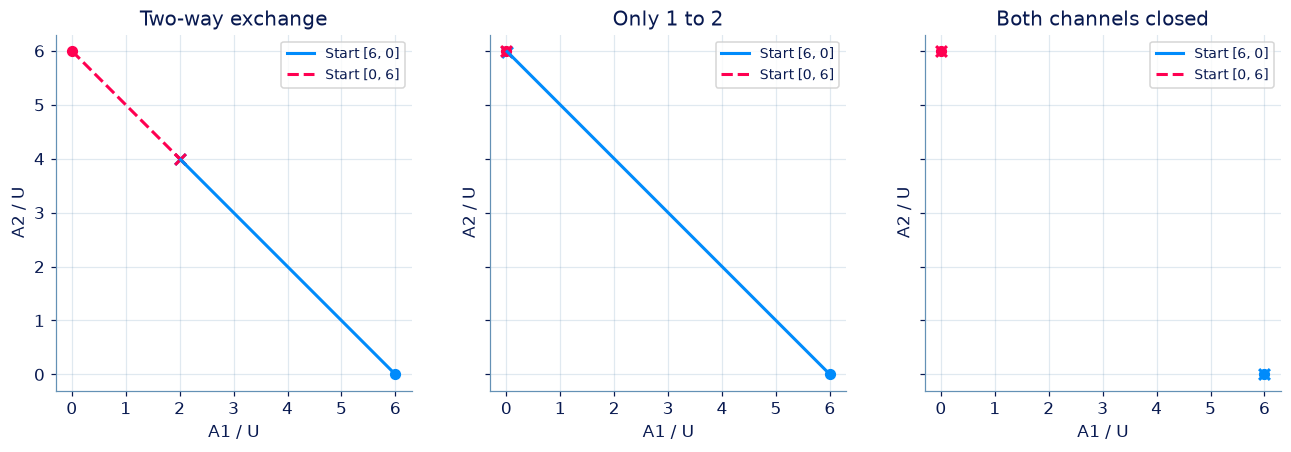

| a / (1/T) | b / (1/T) | A1(30) / U | A2(30) / U |
| --- | --- | --- | --- |
| 0.2 | 0.1 | 2.00049 | 3.99951 |
| 0.2 | 0 | 0.0148725 | 5.98513 |
| 0 | 0.1 | 6 | 0 |
| 0 | 0 | 6 | 0 |

In [4]:
times=np.linspace(0,30,301)
fig,axes=plt.subplots(1,3,figsize=(12,4),sharex=True,sharey=True)
for ax,a,b,title in zip(axes,[.2,.2,0],[.1,0,0],['Two-way exchange','Only 1 to 2','Both channels closed']):
    for initial,style,color in [([6,0],'-',BLUE),([0,6],'--',PINK)]:
        states=np.array(closed_state(a,b,initial,times))
        ax.plot(*states.T,style,color=color,label=f'Start {initial}')
        ax.scatter(*states[0],color=color,marker='o',s=40)
        ax.scatter(*states[-1],color=color,marker='x',s=50)
    ax.set(xlim=(-.3,6.3),ylim=(-.3,6.3),xlabel='A1 / U',ylabel='A2 / U',title=title);ax.set_aspect('equal');ax.legend(fontsize=9)
plt.show()
display(Markdown(show_table(['a / (1/T)','b / (1/T)','A1(30) / U','A2(30) / U'],[(a,b,*closed_state(a,b,[6,0],[30])[0]) for a,b in [(.2,.1),(.2,0),(0,.1),(0,0)]])))

## 结果解释

双向交换时两个不同分配的初值趋向 [2,4]；单向通道时趋向 [0,6]；完全断开则停在各自起点。圆点标起点，叉标 30 T 时的状态；把叉的位置与长期极限（limit）比较，可以看出还剩多少偏差。

### 独立核对

单向时退化为一阶衰减，可直接核对；完全断开必须保留初值而不是均分。

In [5]:
for a,b in [(.2,.1),(.2,0),(0,.1),(0,0)]:
    for initial in [[6,0],[0,6],[2,4]]:
        states=np.array(closed_state(a,b,initial,[0,1,10]))
        np.testing.assert_allclose(states.sum(axis=1),sum(initial))
        np.testing.assert_allclose(states[0],initial)
        assert states.min()>=0
np.testing.assert_allclose(closed_state(.2,0,[6,1],[2])[0],[6*math.exp(-.4),7-6*math.exp(-.4)])
assert closed_state(0,0,[2,4],[0,100])==[[2,4],[2,4]]
print('封闭守恒、单向极限与完全断开边界通过。')

封闭守恒、单向极限与完全断开边界通过。


[观察本章的动态可视化](http://127.0.0.1:8000/chapters/03-03-耦合、相平面与平衡/explore/)：改变一个条件，观察时间曲线与状态空间（state space）中的运动，再回到本节解释。

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · Python 计算题：关闭通道后物质流向哪里

无输入（input）、无清除的封闭两室，a 表示 1→2，b 表示 2→1。给定初值（initial condition），在各时刻返回所追踪物质总量（tracked amount）。允许关闭一个或两个交换通道。

**函数与代码模板**

```python
def solve(
    a: float,
    b: float,
    initial: list[float],
    times: list[float],
) -> list[list[float]]:
    # 根据题意计算，并按约定顺序返回。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `a` | `float` | 室 1 到室 2 的交换系数。 | 1/T |
| `b` | `float` | 室 2 到室 1 的交换系数。 | 1/T |
| `initial` | `list[float]` | 初始 [A1,A2]。 | U |
| `times` | `list[float]` | 所求时刻，顺序保持不变。 | T |

**返回值**

直接返回 states（list[list[float]]）。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `states` | `list[list[float]]` | 每个时刻的 [A1,A2]。 | U |

**计算规则**

总量 S=sum(initial)。a+b>0 时 A1*=bS/(a+b)，A1(t)=A1*+(initial[0]−A1*)exp(−(a+b)t)，A2=S−A1；a=b=0 时保持初值。

**约束与边界**

- 所有数值有限；不修改输入列表。
- 0≤a,b≤1；initial 长度 2，各分量 0—20；times 长度 1—30，0≤t≤30。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| a | 室 1 到室 2 的交换系数。 | 0.2 | 1/T |
| b | 室 2 到室 1 的交换系数。 | 0.1 | 1/T |
| initial | 初始 [A1,A2]。 | [6, 0] | U |
| times | 所求时刻，顺序保持不变。 | [0, 2] | T |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
a = 0.2
b = 0.1
initial = [6, 0]
times = [0, 2]

result = solve(a, b, initial, times)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| states | 每个时刻的 [A1,A2]。 | [[6.0, 0.0], [4.195246544376105, 1.8047534556238942]] | U |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = [[6.0, 0.0],
                   [4.195246544376105, 1.8047534556238942]]
```

**样例解释**

总量为 6 U，平衡（equilibrium）为 [2,4] U；t=2 时 A1=2+4exp(−0.6)，A2=6−A1。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：关闭通道后物质流向哪里](http://127.0.0.1:8000/chapters/03-03-%E8%80%A6%E5%90%88%E3%80%81%E7%9B%B8%E5%B9%B3%E9%9D%A2%E4%B8%8E%E5%B9%B3%E8%A1%A1/practice/?question=p03-closed-state)

### 第 2 题 · 多项选择题：只关闭回流通道

封闭系统 a>0、b=0，总量为 6 U。哪些成立？

- **A.** 长期趋向 [0,6] U。
- **B.** 所追踪物质总量（tracked amount）仍守恒。
- **C.** 只要 b=0，就所有状态（state）都是平衡（equilibrium）。
- **D.** 平衡集合在非负区域为 A1=0、A2 任意非负值。

[作答：只关闭回流通道](http://127.0.0.1:8000/chapters/03-03-%E8%80%A6%E5%90%88%E3%80%81%E7%9B%B8%E5%B9%B3%E9%9D%A2%E4%B8%8E%E5%B9%B3%E8%A1%A1/practice/?question=p03-channel-off)

### 第 3 题 · 多项选择题：拉伸坐标会改变系统吗

同一轨迹（trajectory）把横坐标绘图比例扩大十倍，纵轴不变，时间和数据不变。哪些成立？

- **A.** 外观角度和长度可能变，但方程没有改变。
- **B.** 由图上角度变化可证明耦合系数增大。
- **C.** 比较方向时应读坐标刻度与单位。
- **D.** 若比较欧几里得几何，应采用等比例轴或解释坐标变换。

[作答：拉伸坐标会改变系统吗](http://127.0.0.1:8000/chapters/03-03-%E8%80%A6%E5%90%88%E3%80%81%E7%9B%B8%E5%B9%B3%E9%9D%A2%E4%B8%8E%E5%B9%B3%E8%A1%A1/practice/?question=p03-axis-scale)

### 第 4 题 · 单项选择题：两个通道都关闭

封闭两室 a=b=0，从 [2,4] 开始。下列哪项正确？

- **A.** 最终自动均分为 [3,3]。
- **B.** 保持 [2,4]，且非负区域的每个状态（state）都是平衡（equilibrium）。
- **C.** 总量会衰减到零。
- **D.** 模型（model）必须产生振荡才能保持守恒。

[作答：两个通道都关闭](http://127.0.0.1:8000/chapters/03-03-%E8%80%A6%E5%90%88%E3%80%81%E7%9B%B8%E5%B9%B3%E9%9D%A2%E4%B8%8E%E5%B9%B3%E8%A1%A1/practice/?question=p03-all-channels-off)

**进一步阅读**

[MIT 一阶系统课程](https://ocw.mit.edu/courses/18-03sc-differential-equations-fall-2011/pages/unit-iv-first-order-systems/)：矩阵方法、矩阵指数、相图与线性化。